In [27]:
import pandas as pd
df = pd.read_csv('./data/AB_Test_Results.csv')
print(df.head())

   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0


In [28]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


,USER_ID,REVENUE
count,10000.000000,10000.000000
mean,4981.080200,0.099447
std,2890.590115,2.318529
min,2.000000,0.000000
25%,2468.750000,0.000000
50%,4962.000000,0.000000
75%,7511.500000,0.000000
max,10000.000000,196.010000


In [29]:
df = df.drop_duplicates()

In [38]:
df = df.groupby(['USER_ID','VARIANT_NAME'])['REVENUE'].sum().reset_index()

In [40]:
import numpy as np
df['convert'] = np.select([df['REVENUE']>0],[1],default=0)
group_df = df.groupby(['VARIANT_NAME']).agg(
    size=('USER_ID','count'),
    mean=('REVENUE','mean'),
    convert=('convert','sum')
).reset_index()
group_df['cvr'] = group_df['convert']/group_df['size']
group_df

,VARIANT_NAME,size,mean,convert,cvr
0,control,3931,0.163572,80,0.020351
1,variant,3934,0.089342,71,0.018048


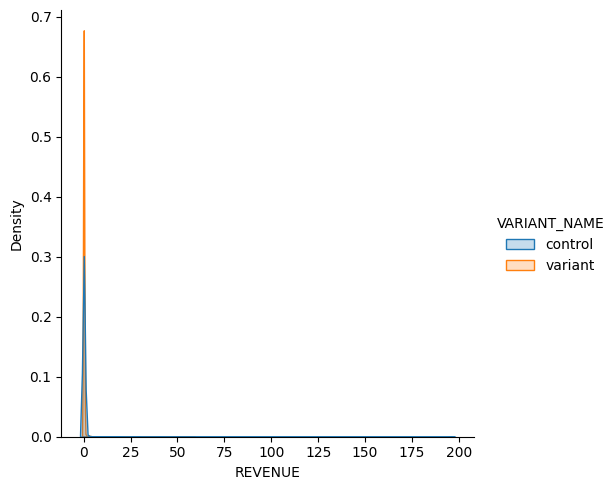

In [41]:
import seaborn as sns
sns.displot(
    data=df,
    x="REVENUE",
    hue="VARIANT_NAME",
    kind='kde',
    fill=True
)

<Axes: xlabel='VARIANT_NAME', ylabel='REVENUE'>

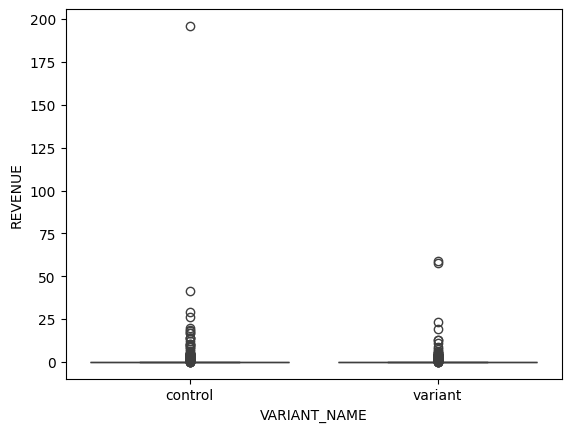

In [43]:
sns.boxplot(data=df, x='VARIANT_NAME', y='REVENUE')

In [44]:
df.groupby('VARIANT_NAME')['REVENUE'].mean()

VARIANT_NAME
control    0.163572
variant    0.089342
Name: REVENUE, dtype: float64

## Test Conversion Rate using Z Test

In [53]:
control = df[df['VARIANT_NAME']=='control']['convert']
treatment = df[df['VARIANT_NAME']=='variant']['convert']
diffs = []
for i in range(5000):
    c = control.sample(frac=1, replace=True)
    t = treatment.sample(frac=1, replace=True)
    diffs.append(t.mean() - c.mean())
diffs = np.array(diffs)
lower = np.quantile(diffs,0.025)
upper = np.quantile(diffs,0.975)
print(f'CI: {lower:.4f} - {upper:.4f}')

CI: -0.0084 - 0.0038


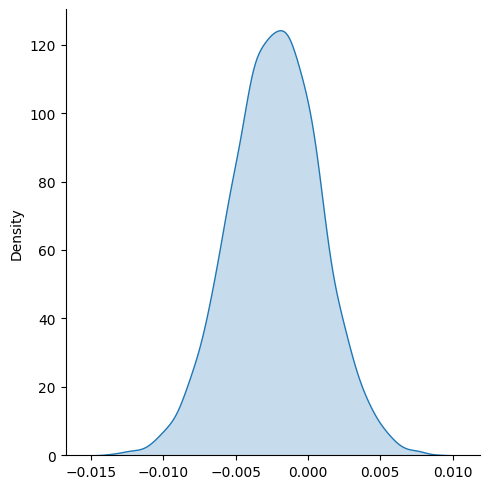

In [54]:
sns.displot(diffs,kind='kde',fill=True)

Text(0.5, 1.0, 'QQ Plot')

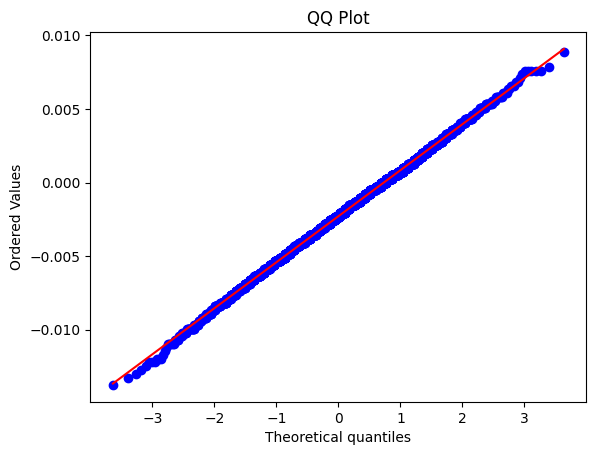

In [55]:
import matplotlib.pyplot as plt
from scipy import stats
stats.probplot(diffs,dist='norm',plot=plt)
plt.title('QQ Plot')

In [47]:
from statsmodels.stats.proportion import proportions_ztest
total = group_df['size'].values
success = group_df['convert'].values
z_stat, p_value = proportions_ztest(success, total)
print(f"Z-statistic: {z_stat:.4f}, P-value: {p_value:.4f}")

Z-statistic: 0.7443, P-value: 0.4567


## Bootstraping / Mann Whiteney for Revenue / log revenue then do t test (can segment only spenders)

In [56]:
import numpy as np
control = df[df['VARIANT_NAME']=='control']['REVENUE']
treatment = df[df['VARIANT_NAME']=='variant']['REVENUE']
observed_diff = treatment.mean() - control.mean()

diffs = []
for _ in range(5000):
    c = control.sample(frac=1, replace=True)
    t = treatment.sample(frac=1, replace=True)
    diffs.append(t.mean() - c.mean())
diffs = np.array(diffs)
lower = np.quantile(diffs, 0.025)
upper = np.quantile(diffs, 0.975)
p_value = (np.sum(diffs>=0) + 1) / (len(diffs)+1)
print(f"95% CI for the difference in mean revenue: [{lower}, {upper}]")
print(f"P-value: {p_value}")

95% CI for the difference in mean revenue: [-0.21141696207339697, 0.024608913050450713]
P-value: 0.08398320335932813


<Figure size 1000x600 with 0 Axes>

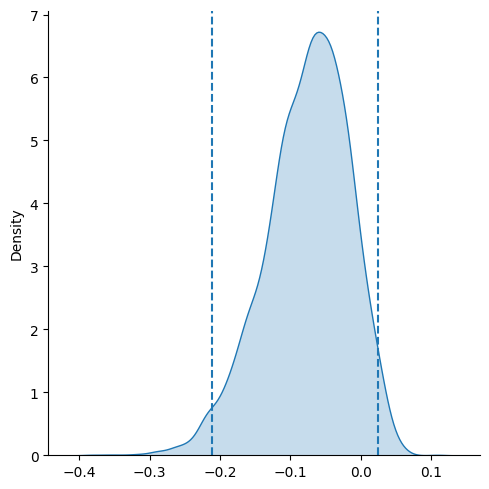

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.displot(diffs,kind='kde',fill=True)
plt.axvline(lower, linestyle='--')
plt.axvline(upper, linestyle='--')
plt.show()

In [59]:
# paired t test since users can be in control and variant groups
import pingouin
pingouin.ttest(treatment,control,paired=True)

/Users/reynafeng/Documents/Git/experiment/.venv/lib/python3.14/site-packages/pingouin/parametric.py:225: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-1.258984,5386.433536,two-sided,0.208091,"[-0.19, 0.04]",0.0284,0.242354,0.056


## Mann Whitney Check

In [50]:
from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(control, treatment, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat}, P-value: {p_value}")

Mann-Whitney U statistic: 7750519.5, P-value: 0.4459080979612927


In [51]:
import pingouin
pingouin.mwu(control, treatment)

,U_val,alternative,p_val,RBC,CLES
MWU,7750519.5,two-sided,0.445908,0.002359,0.50118


## Log Transform T Test

/var/folders/01/fn6y_26n2kg0vjzvh7y6cjm80000gn/T/ipykernel_46449/2862275390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  converted_df['log_revenue'] = np.log1p(converted_df['REVENUE'])
/var/folders/01/fn6y_26n2kg0vjzvh7y6cjm80000gn/T/ipykernel_46449/2862275390.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 400x200 with 0 Axes>

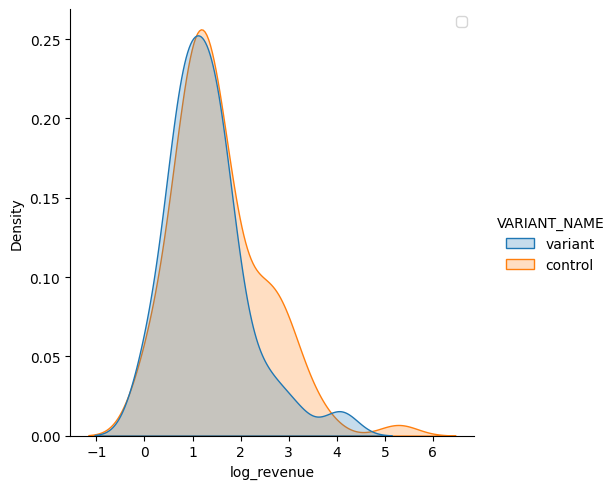

In [66]:
df['log_revenue'] = np.log1p(df['REVENUE'])
converted_df = df[df['convert'] == 1]
converted_df['log_revenue'] = np.log1p(converted_df['REVENUE'])
plt.figure(figsize=(4,2))
sns.displot(converted_df,x='log_revenue',kind='kde',hue='VARIANT_NAME',fill=True)
plt.legend()
plt.show()

In [73]:
control = converted_df[converted_df['VARIANT_NAME']=='control']['log_revenue']
treatment = converted_df[converted_df['VARIANT_NAME']=='variant']['log_revenue']
pingouin.ttest(treatment,control)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-1.653731,148.947989,two-sided,0.100288,"[-0.52, 0.05]",0.267413,0.370699,0.613
